# Chapter 5: Deep Learning on Sequence Data

## Instructor: Rahul Bhadani

In [4]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
# At the top of your notebook, add:
np.set_printoptions(suppress=True, precision=8)
torch.set_printoptions(sci_mode=False, precision=8)

import torch.nn.functional as F
from PIL import Image

cuda


# 1. Example of Filters

In [5]:
edge_filter = torch.tensor([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]], dtype=torch.float32)

# Sobel - Horizontal
sobel_x = torch.tensor([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=torch.float32)

# Sobel - Vertical
sobel_y = torch.tensor([[1, 2, 1],
                        [0, 0, 0],
                        [-1, -2, -1]], dtype=torch.float32)

# Prewitt - Horizontal
prewitt_x = torch.tensor([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]], dtype=torch.float32)

# Prewitt - Vertical
prewitt_y = torch.tensor([[1, 1, 1],
                        [0, 0, 0],
                        [-1, -1, -1]], dtype=torch.float32)

# Roberts Cross (3x3 version) - Diagonal
roberts_x = torch.tensor([[0, 0, 0],
                        [0, 1, -1],
                        [0, 0, 0]], dtype=torch.float32)

# Roberts Cross (3x3 version) - Anti-diagonal
roberts_y = torch.tensor([[0, 0, 0],
                        [0, 1, 0],
                        [0, -1, 0]], dtype=torch.float32)

# Laplacian - 4-connectivity
laplacian_4 = torch.tensor([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]], dtype=torch.float32)

# Laplacian - 8-connectivity
laplacian_8 = torch.tensor([[1, 1, 1],
                            [1, -8, 1],
                            [1, 1, 1]], dtype=torch.float32)

# Kirsch - North
kirsch_n = torch.tensor([[-3, -3, -3],
                        [-3, 0, -3],
                        [5, 5, 5]], dtype=torch.float32)

# Kirsch - East
kirsch_e = torch.tensor([[-3, -3, 5],
                        [-3, 0, 5],
                        [-3, -3, 5]], dtype=torch.float32)

# Robinson - North
robinson_n = torch.tensor([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=torch.float32)

# Frei-Chen
frei_chen = torch.tensor([[1/torch.sqrt(torch.tensor(2.0)), 0, -1/torch.sqrt(torch.tensor(2.0))],
                        [1, 0, -1],
                        [1/torch.sqrt(torch.tensor(2.0)), 0, -1/torch.sqrt(torch.tensor(2.0))]], dtype=torch.float32)

sobel_filter = torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=torch.float32)

## Read an image

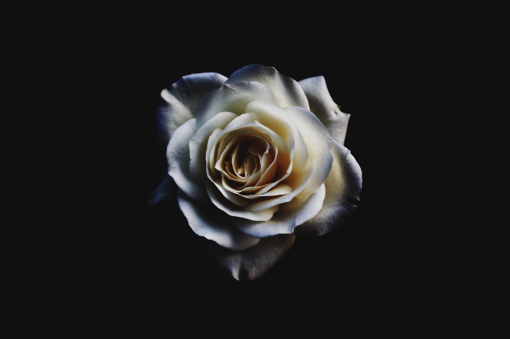

In [8]:
img = Image.open('rose.png').convert('RGB')
img

In [9]:
torch.from_numpy(np.array(img)).shape

torch.Size([339, 510, 3])

We want to change the order from Height x Width x  Channel to (Channels x Height x Width), or (Batch x Channels x Height x Width) for batches

In [10]:
img_tensor = torch.from_numpy(np.array(img)).float() / 255.0

# We want to change the order from Height x Width x  Channel to (Channels x Height x Width), or (Batch x Channels x Height x Width) for batches
img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)

img_tensor.shape

torch.Size([1, 3, 339, 510])

In [11]:
# Reshape filter: (1, 1, 3, 3) for conv2d
kernel = edge_filter.unsqueeze(0).unsqueeze(0)
kernel.shape

torch.Size([1, 1, 3, 3])

In [12]:
# Apply filter to each channel
result_channels = []
for i in range(3):  # RGB
    
    # extracts single 4D Tensor Corresponding to each channel
    channel = img_tensor[:, i:i+1, :, :]
    
    # apply convolution 
    filtered = F.conv2d(channel, kernel, padding=1)
    result_channels.append(filtered)

In [13]:
# Combine channels
filtered_img = torch.cat(result_channels, dim=1)

In [14]:
# Convert back to numpy for saving/display
output = filtered_img.squeeze(0).permute(1, 2, 0).numpy()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.282353].


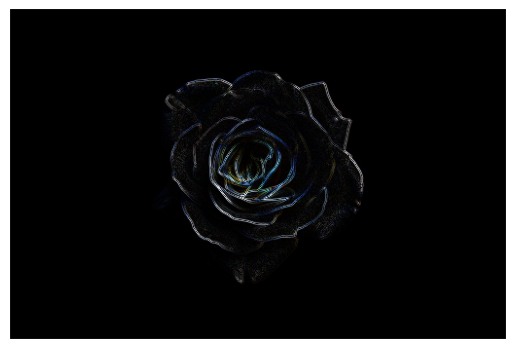

In [15]:
# Save or display
import matplotlib.pyplot as plt
plt.imshow(np.abs(output), cmap='gray')
plt.axis('off')
plt.show()

In [16]:
def apply_filter(img, filter):
    """
    Apply Filter to image

    Args:
        img (4 D Tensor): Input Image
        filter (4 D Tensor):  Input Filter
    """
    img_tensor = torch.from_numpy(np.array(img)).float() / 255.0
    img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)
    kernel = filter.unsqueeze(0).unsqueeze(0)
    
    # Apply filter to each channel
    result_channels = []
    for i in range(3):  # RGB
        
        # extracts single 4D Tensor Corresponding to each channel
        channel = img_tensor[:, i:i+1, :, :]
        
        # apply convolution 
        filtered = F.conv2d(channel, kernel, padding=1)
        result_channels.append(filtered)
        
    # Combine channels
    filtered_img = torch.cat(result_channels, dim=1)
    
    # Convert back to numpy for saving/display
    output = filtered_img.squeeze(0).permute(1, 2, 0).numpy()
    
    # Normalize to [0, 1] range
    # because some filters produce values outside range 0 and 1
    #output = (output - output.min()) / (output.max() - output.min())
    
    # Save or display
    import matplotlib.pyplot as plt
    plt.imshow(output, cmap='gray')
    plt.axis('off')
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.282353..1.090196].


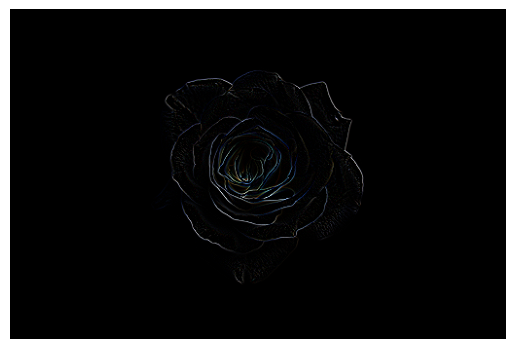

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0509803..2.8313725].


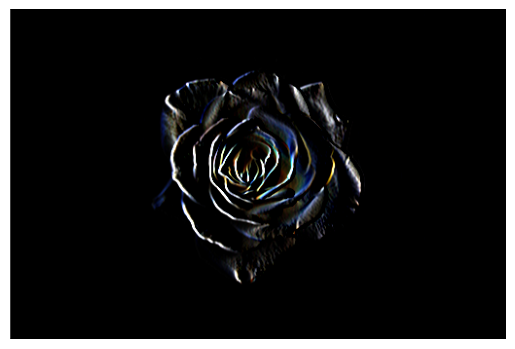

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.964706..3.152941].


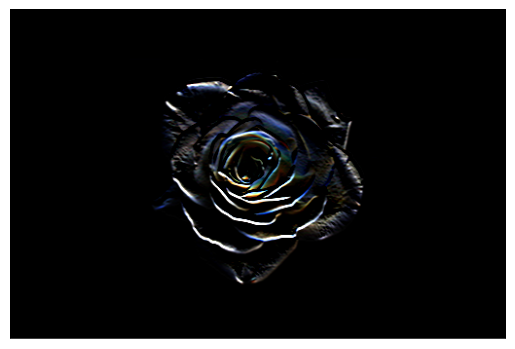

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2666664..2.1176472].


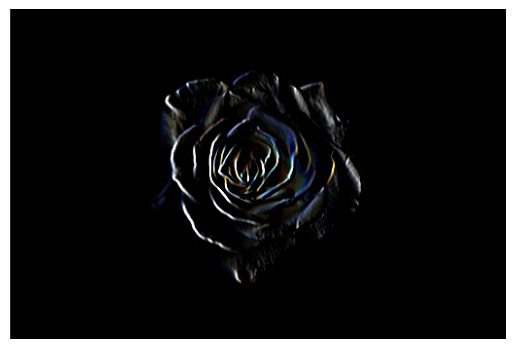

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2117648..2.3647058].


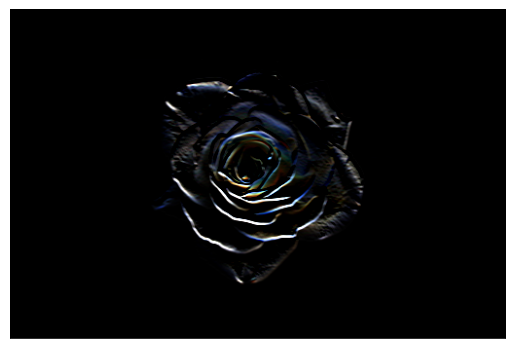

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.59607846..0.6].


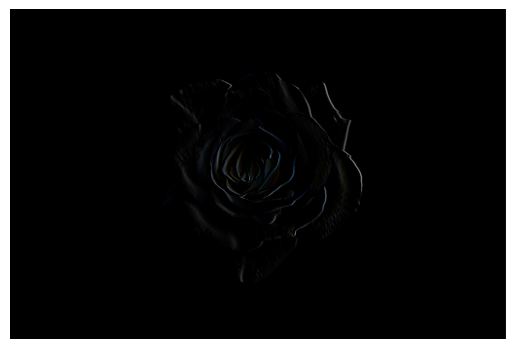

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5882353..0.6156863].


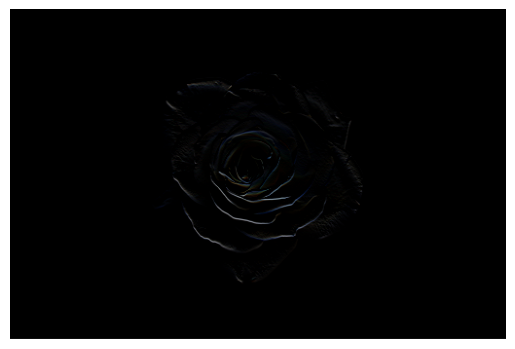

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.282353..1.090196].


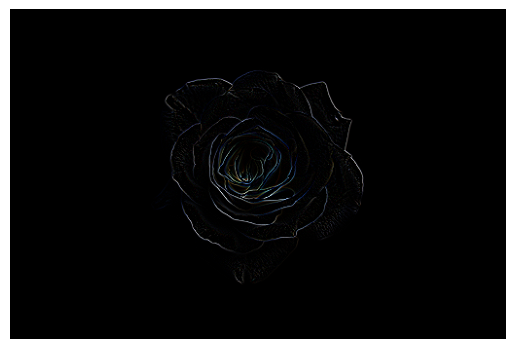

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7843137..2.5411766].


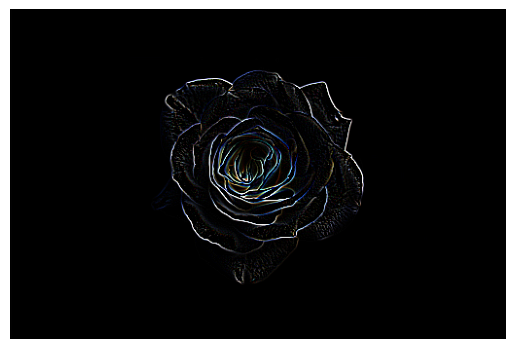

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.67451..9.819608].


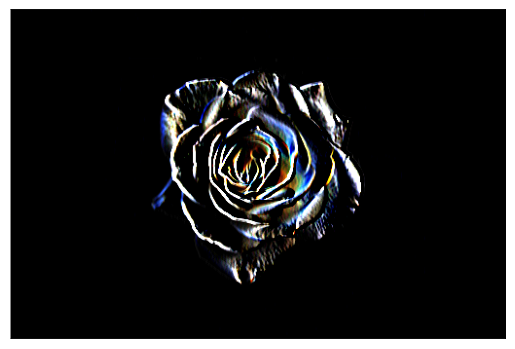

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-10.082354..9.57647].


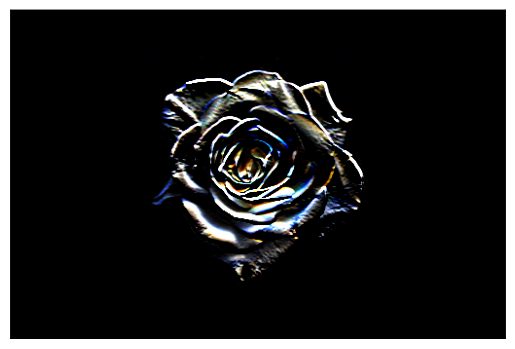

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.706448..1.8324955].


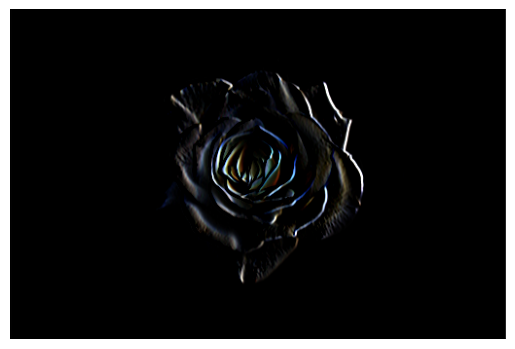

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8313725..3.0509803].


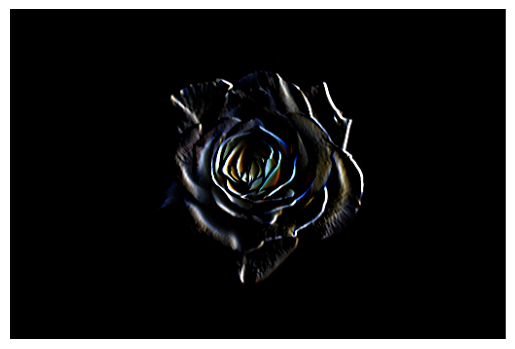

In [17]:
filters = [edge_filter, sobel_x, sobel_y,  prewitt_x, prewitt_y, roberts_x, roberts_y,laplacian_4, laplacian_8, kirsch_e, kirsch_n, frei_chen, sobel_filter]
for f in filters:
    apply_filter(img=img, filter=f)

# 2. Understanding Convolution Layer in PyTorch

`conv2d` in PyTorch

https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

It performs the following operation:

$$
(f*k)(i, j) = \sum_m \sum_n f(i+m, j + n) \cdot k(m, n)
$$

**Note:** The kernel is flipped in true mathematical convolution, but PyTorch does not flip the kernel – it performs cross‑correlation. This does not affect the network’s ability to learn because the kernels are learned from scratch.

In [18]:
import torch
import torch.nn as nn

# Create a Conv2d layer
conv = nn.Conv2d(in_channels=1,    # grayscale image
                    out_channels=4,   # number of filters
                    kernel_size=3,    # 3x3 kernel
                    stride=1,
                    padding=0)

# Random input: batch size 2, 1 channel, 5x6 image
x = torch.randn(2, 1, 5, 6)
print(f"x ={x}")
print("Input shape:  ", x.shape)


print(f"Convolution Weight: {conv.weight}")

print(f"Convolution Bias: {conv.bias}")

print(f"Convolution Weight Shape: {conv.weight.shape}")

# Forward pass
out = conv(x)
print("Output shape: ", out.shape)

x =tensor([[[[ 0.53545296,  1.01638520,  0.37524438, -0.07541756, -0.36291295,
            0.75696081],
          [ 0.61835504,  0.55351865,  0.36776587,  0.48928082, -1.37783957,
            0.65358835],
          [-0.40576121,  0.34671527, -1.90501344,  0.24643369, -1.17314506,
            0.02563816],
          [ 0.29449672,  0.72401726,  0.11839127, -0.69832158,  0.29334494,
           -1.39124930],
          [ 0.29872668,  0.03891716, -0.29892501,  0.70063174,  0.02338107,
            0.95414501]]],


        [[[ 0.25101545, -0.90654278, -1.76333189, -0.41707060,  0.33205196,
            0.02834974],
          [-0.21397039, -0.98435295,  1.99001825,  0.71620697, -0.64904583,
            2.19593620],
          [ 0.68984973,  0.56800050, -0.42608136,  0.45338681, -0.10999586,
           -0.80905503],
          [-0.58036143,  2.42707014,  1.30134332,  0.49797857,  0.44274184,
           -1.46034598],
          [-0.68065119,  0.39786628, -0.05533619,  1.30442536,  0.88333112,
        

In [19]:
5 - 3 + 1,6 - 3 + 1

(3, 4)

We used 4 filters

Batch size stays 2

Hence: Output shape:  torch.Size([2, 4, 3, 4]) = batch_size  x filters x height x width

## Padding

Adding padding allows the convolution to be applied to border pixels and can keep the spatial size unchanged.

In [20]:
conv_pad = nn.Conv2d(1, 3, kernel_size=3, stride=1, padding=1)
out = conv_pad(x)
print("With padding=1:", out.shape)

With padding=1: torch.Size([2, 3, 5, 6])


## Stride
Stride > 1 down‑samples the feature map.

In [21]:
conv_stride2 = nn.Conv2d(1, 3, kernel_size=3, stride=2, padding=1)
out = conv_stride2(x)
print("Stride=2, padding=1:", out.shape)

Stride=2, padding=1: torch.Size([2, 3, 3, 3])


⌊(5+2−3)/2+1⌋=⌊4/2+1⌋=3.

## Learnable Parameters

Weight Tensor has shape :  no. of output channel x (input channel/groups) x kernesize[0] x kernelsize[1]

Bias Tensor is 1D Tensor of size of output channel

From documentation (https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html): 

`groups` controls the connections between inputs and outputs. `in_channels` and `out_channels` must both be divisible by groups. For example,

At `groups=1`, all inputs are convolved to all outputs.

At `groups=2`, the operation becomes equivalent to having two conv layers side by side, each seeing half the input channels and producing half the output channels, and both subsequently concatenated.

At `groups= in_channels`, each input channel is convolved with its own set of filters (of size `out_channels`/`in_channels`)



## Your own Conv2D

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Conv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super(Conv2d, self).__init__()
        
        # Store hyperparameters
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding if isinstance(padding, tuple) else (padding, padding)
        
        # Initialize learnable parameters
        self.weight = nn.Parameter(torch.randn(out_channels, in_channels, *self.kernel_size))
        if bias:
            self.bias = nn.Parameter(torch.zeros(out_channels))
        else:
            self.register_parameter('bias', None)
        
        # Initialize weights properly
        self.reset_parameters()
    
    def reset_parameters(self):
        # Kaiming initialization
        nn.init.kaiming_uniform_(self.weight, a=torch.nn.init.calculate_gain('relu'))
        if self.bias is not None:
            nn.init.zeros_(self.bias)
    
    def forward(self, x):
        # Use PyTorch's built-in conv2d function
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding)

# Usage example
conv = Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
x = torch.randn(1, 3, 32, 32)  # batch_size=1, channels=3, height=32, width=32
output = conv(x)
print(output.shape)  # torch.Size([1, 16, 32, 32])

torch.Size([1, 16, 32, 32])


# 2. Building an image classifier using Convolutional Network

In [ ]:
!wget https://github.com/rahulbhadani/CPE487587_SP26/releases/download/catsdogs/CatsDogs.zip 
!unzip CatsDogs.zip -d ../Data

--2026-02-12 12:35:45--  https://github.com/rahulbhadani/CPE487587_SP26/releases/download/catsdogs/CatsDogs.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1114123636/408d211b-4bbe-496d-a7ec-7a7875587dd9?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-12T19%3A14%3A24Z&rscd=attachment%3B+filename%3DCatsDogs.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-12T18%3A13%3A34Z&ske=2026-02-12T19%3A14%3A24Z&sks=b&skv=2018-11-09&sig=dXKCC6ez1VimPrpvBVM4Jzehmj0zojC29ZbpU2Lz1EM%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MDkyNDk0NSwibmJmIjoxNzcwOTIxMzQ1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvb

In [25]:
!ls -lrt ../Data/CatsDogs/PetImages

total 3723
drwxrwxr-x 2 rkb0022 ds_uah_users   268 Apr  1  2024 Dog_Small
drwxrwxr-x 2 rkb0022 ds_uah_users 12472 Apr  1  2024 Dog
drwxrwxr-x 2 rkb0022 ds_uah_users   133 Apr  1  2024 Cat_Small
drwxrwxr-x 2 rkb0022 ds_uah_users 12493 Apr  1  2024 Cat


In [64]:
# Define the CNN architecture
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()
         # First convolutional layer: 3 input channels (RGB images), 16 output channels (filters), 3x3 kernel, and padding of 1
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # Second convolutional layer: 16 input channels, 32 output channels, 3x3 kernel, and padding of 1
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Max-pooling layer: 2x2 kernel and stride of 2 (reduces spatial dimensions by half)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # First fully connected layer: 32*32*32 input features (flattened), 128 output features
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        # Final fully connected layer: 128 input features, 2 output features (cat or dog)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: cat and dog

    def forward(self, x):
         # Apply conv1, ReLU activation, and max-pooling
        x = self.pool(torch.relu(self.conv1(x)))
        # Apply conv2, ReLU activation, and max-pooling
        x = self.pool(torch.relu(self.conv2(x)))
         # Flatten the output tensor to a 1D vector
        x = x.view(-1, 32 * 32 * 32)
       # Pass through fc1 with ReLU activation
        x = torch.relu(self.fc1(x))
        # Compute output logits using fc2
        x = self.fc2(x)
        return x

In [65]:
# Load and preprocess data
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize pixel values
])

In [66]:
from torch.utils.data import DataLoader, Dataset

In [67]:
# Define the CatDogDataset class
import os
class CatDogDataset(Dataset):
    def __init__(self, root_folder, transform=None):
        """
        Args:
            root_folder (str): Path to the root folder containing cat and dog images.
            transform (callable, optional): Optional transform to apply to the images.
        """
        # Set the root folder path
        self.root = root_folder
        # Store the image transformation function (if provided)
        self.transform = transform
        # Define the classes (assuming subfolders are named "cat" and "dog")
        #self.classes = ["Cat_Small", "Dog_Small"]
        self.classes = ["Cat", "Dog"]
        # Initialize an empty list to store image filenames
        self.elements = []

        # Collect image filenames
        for class_name in self.classes:
            # Create the full path to the class-specific folder
            class_folder = os.path.join(self.root, class_name)
            # Iterate through files in the class folder
            for filename in os.listdir(class_folder):
                # Check if the file has a ".jpg" extension
                if filename.endswith(".jpg"):
                    # Append the full path of the image file to the list
                    self.elements.append(os.path.join(class_name, filename))

    def __len__(self):
        # Return the total number of images in the dataset
        return len(self.elements)

    def __getitem__(self, index):
        # Open the image using PIL (Pillow)
        img = Image.open(os.path.join(self.root, self.elements[index].rstrip()))
        # Convert the image to RGB format (if it was grayscale)
        img = img.convert("RGB")
        # Determine the target label (index of the class in self.classes)
        target = self.classes.index(self.elements[index].rstrip().split('/')[0])
        # Return the image and its corresponding label
        image, label = img, target

        # Apply the specified transformation (if provided)
        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [68]:
# Create training and test datasets
root_folder = '../Data/CatsDogs/PetImages'
dataset = CatDogDataset(root_folder, transform=transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.827451].


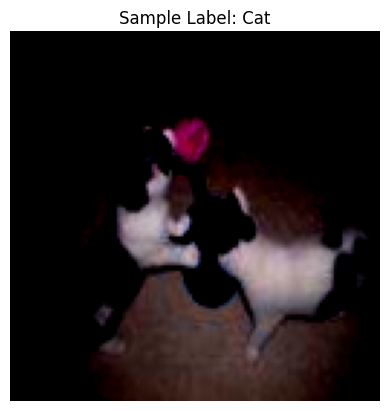

In [69]:
# Visualize a random sample
import numpy as np
random_idx = np.random.randint(len(dataset))
sample_img, sample_label = dataset[random_idx]

# Convert the PyTorch tensor to a NumPy array
sample_img_np = sample_img.numpy().transpose(1, 2, 0)  # Channels last

# Display the image
plt.imshow(sample_img_np)
plt.title(f"Sample Label: {'Cat' if sample_label == 0 else 'Dog'}")
plt.axis('off')
plt.show()

In [70]:
# Split the dataset into train and test sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

from torch.utils.data import DataLoader, random_split
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 19967
Test dataset size: 4992


In [71]:
# Initialize the model and optimizer
model = CatDogCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [72]:
num_epochs = 300
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize lists to store loss values and epochs
loss_values = []
epochs = range(1, num_epochs + 1)

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # Clear gradients before computing new ones
        outputs = model(images)  #images, labels = images.to(device), labels.to(device) Forward pass: compute model predictions
        loss = criterion(outputs, labels)  # Compute the loss
        loss.backward()  # Backpropagation: compute gradients
        optimizer.step()  # Update model parameters using gradients

    # Append the loss value for this epoch
    loss_values.append(loss.item())
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {loss.item():.4f}")


# Create a plot for loss vs. epoch
plt.figure(figsize=(8, 6))
plt.plot(epochs, loss_values, marker='o', linestyle='-', color='b')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epoch')
plt.grid(True)
plt.show()

/home/rkb0022/CPE487587_SP26/Code/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/300] - Loss: 0.7150
Epoch [2/300] - Loss: 0.4704
Epoch [3/300] - Loss: 0.4684
Epoch [4/300] - Loss: 0.4384
Epoch [5/300] - Loss: 0.1245
Epoch [6/300] - Loss: 0.1282
Epoch [7/300] - Loss: 0.0788
Epoch [8/300] - Loss: 0.0132
Epoch [9/300] - Loss: 0.0591
Epoch [10/300] - Loss: 0.0198
Epoch [11/300] - Loss: 0.0064
Epoch [12/300] - Loss: 0.0121
Epoch [13/300] - Loss: 0.0374
Epoch [14/300] - Loss: 0.0172
Epoch [15/300] - Loss: 0.0015
Epoch [16/300] - Loss: 0.0035
Epoch [17/300] - Loss: 0.0018
Epoch [18/300] - Loss: 0.0093
Epoch [19/300] - Loss: 0.0235
Epoch [20/300] - Loss: 0.0962
Epoch [21/300] - Loss: 0.0076
Epoch [22/300] - Loss: 0.0228
Epoch [23/300] - Loss: 0.0025
Epoch [24/300] - Loss: 0.0626
Epoch [25/300] - Loss: 0.0625
Epoch [26/300] - Loss: 0.0254
Epoch [27/300] - Loss: 0.0123
Epoch [28/300] - Loss: 0.0022
Epoch [29/300] - Loss: 0.0001
Epoch [30/300] - Loss: 0.0001
Epoch [31/300] - Loss: 0.0001
Epoch [32/300] - Loss: 0.0001
Epoch [33/300] - Loss: 0.0002
Epoch [34/300] - Lo

KeyboardInterrupt: 

In [73]:
# Evaluate the model on the test set
test_loader = DataLoader(test_dataset, batch_size=batch_size)
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 77.58%


In [74]:
device

device(type='cuda')

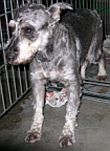

In [75]:
# Load the input image
input_image_path = '../Data/CatsDogs/PetImages/Dog/10001.jpg'
input_image = Image.open(input_image_path)
input_image

In [76]:
input_tensor = transform(input_image).unsqueeze(0)  # Add batch dimension

input_tensor = input_tensor.to(device)
# Make predictions
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted_class = torch.max(outputs, 1)

# Map class index to label (0 for cat, 1 for dog)
class_labels = ['Cat', 'Dog']
predicted_label = class_labels[predicted_class.item()]

print(f"Predicted label: {predicted_label}")

Predicted label: Dog


# 3. Recurrent Neural Network

## RNN Cell: Recurrent Connection

In [ ]:
import torch
import torch.nn as nn

class RNNCell(nn.Module):
    """
    Single RNN Cell implementing: h_t = tanh(xW + h_{t-1}U + b)
    """
    def __init__(self, input_size: int, hidden_size: int):
        super(RNNCell, self).__init__()
        self.hidden_size = hidden_size

        # Input-to-hidden layer
        self.W = nn.Linear(input_size, hidden_size)
        # Hidden-to-hidden layer
        self.U = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x: torch.Tensor, h_prev: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x:      (batch_size, input_size)  — current input
            h_prev: (batch_size, hidden_size) — previous hidden state
        Returns:
            h_t:    (batch_size, hidden_size) — new hidden state
        """
        return torch.tanh(self.W(x) + self.U(h_prev))

In [12]:
import torch
import torch.nn as nn

input_size  = 5
hidden_size = 8
seq_len     = 5
batch_size  = 1

cell = RNNCell(input_size, hidden_size)

# Simulate a sequence: (seq_len, batch, input_size)
x = torch.randn(seq_len, batch_size, input_size)

# Initial hidden state
h_t = torch.zeros(batch_size, hidden_size)

print("Stepping through time:\n")
for t in range(seq_len):
    print(f"Shape of Input = {x[t].shape}")
    h_t = cell(x[t], h_t)   # feed one step at a time
    print(f"  t={t} | input: {x[t].shape} | h_t: {h_t.shape} | h_t norm: {h_t.norm().item():.4f}")

print(f"\nFinal hidden state:\n{h_t}")

Stepping through time:

Shape of Input = torch.Size([1, 5])
  t=0 | input: torch.Size([1, 5]) | h_t: torch.Size([1, 8]) | h_t norm: 1.2090
Shape of Input = torch.Size([1, 5])
  t=1 | input: torch.Size([1, 5]) | h_t: torch.Size([1, 8]) | h_t norm: 1.4597
Shape of Input = torch.Size([1, 5])
  t=2 | input: torch.Size([1, 5]) | h_t: torch.Size([1, 8]) | h_t norm: 1.4977
Shape of Input = torch.Size([1, 5])
  t=3 | input: torch.Size([1, 5]) | h_t: torch.Size([1, 8]) | h_t norm: 1.5186
Shape of Input = torch.Size([1, 5])
  t=4 | input: torch.Size([1, 5]) | h_t: torch.Size([1, 8]) | h_t norm: 1.3078

Final hidden state:
tensor([[-0.5078,  0.8292, -0.2040, -0.3250,  0.3837, -0.3105, -0.2892, -0.5388]],
       grad_fn=<TanhBackward0>)


All hidden states shape: torch.Size([6, 1, 8])


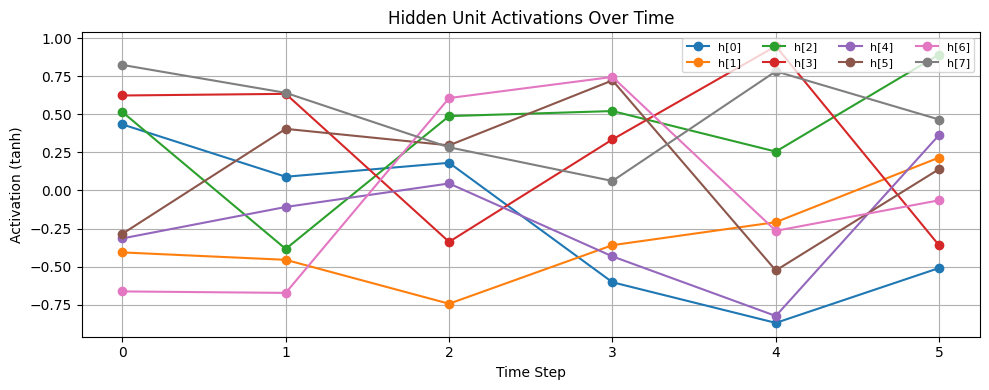

In [15]:
cell = nn.RNNCell(input_size=5, hidden_size=8)

x   = torch.randn(6, 1, 5)   # 6 time steps
h_t = torch.zeros(1, 8)

history = []  # store all hidden states

for t in range(6):
    h_t = cell(x[t], h_t)
    history.append(h_t.detach().clone())

# Stack into (seq_len, batch, hidden)
all_hidden = torch.stack(history, dim=0)
print(f"All hidden states shape: {all_hidden.shape}")  # (6, 1, 8)

# Visualize how each hidden unit evolves over time
import matplotlib.pyplot as plt

values = all_hidden[:, 0, :].numpy()  # (6, 8)

plt.figure(figsize=(10, 4))
for unit in range(8):
    plt.plot(values[:, unit], marker='o', label=f'h[{unit}]')

plt.title("Hidden Unit Activations Over Time")
plt.xlabel("Time Step")
plt.ylabel("Activation (tanh)")
plt.legend(loc='upper right', ncol=4, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
cell = nn.RNNCell(input_size=5, hidden_size=8)

# Start with a strong hidden state, then feed zero inputs
h_t        = torch.ones(1, 8)                    # kick it with a strong state
zero_input = torch.zeros(1, 5)                   # no new information

# no new information so hidden state convergence
print("Decay with zero input:\n")
print(f"  init  | h_t norm: {h_t.norm().item():.4f} | values: {h_t.detach().numpy().round(3)}")

for t in range(30):
    h_t = cell(zero_input, h_t)
    print(f"  t={t}   | h_t norm: {h_t.norm().item():.4f} | values: {h_t.detach().numpy().round(3)}")


Decay with zero input:

  init  | h_t norm: 2.8284 | values: [[1. 1. 1. 1. 1. 1. 1. 1.]]
  t=0   | h_t norm: 2.0243 | values: [[ 0.302 -0.49  -0.585 -0.902  0.795  0.888 -0.649 -0.877]]
  t=1   | h_t norm: 1.4309 | values: [[-0.252 -0.816 -0.733  0.52  -0.171 -0.238 -0.291 -0.583]]
  t=2   | h_t norm: 0.8274 | values: [[-0.685 -0.032 -0.127  0.309 -0.082 -0.234  0.199  0.049]]
  t=3   | h_t norm: 0.6838 | values: [[-0.384  0.204  0.014 -0.427  0.164  0.041 -0.257  0.035]]
  t=4   | h_t norm: 0.6889 | values: [[-0.15  -0.285 -0.279 -0.265  0.061 -0.006 -0.339 -0.322]]
  t=5   | h_t norm: 0.6668 | values: [[-0.397 -0.353 -0.273  0.12  -0.    -0.122 -0.116 -0.213]]
  t=6   | h_t norm: 0.5102 | values: [[-0.433 -0.114 -0.125 -0.086  0.049 -0.079 -0.159 -0.054]]
  t=7   | h_t norm: 0.5306 | values: [[-0.307 -0.16  -0.159 -0.205  0.059 -0.045 -0.257 -0.152]]
  t=8   | h_t norm: 0.5611 | values: [[-0.326 -0.265 -0.213 -0.075  0.035 -0.075 -0.209 -0.193]]
  t=9   | h_t norm: 0.5335 | values: [

## Recurrent Neural Network

In [22]:
class RNN(nn.Module):
    """
    Processes a sequence by unrolling an RNNCell over each time step.
    """
    def __init__(self, input_size: int, hidden_size: int):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.cell = RNNCell(input_size, hidden_size)

    def forward(self, x: torch.Tensor, h_0: torch.Tensor = None):
        """
        Args:
            x:   (batch_size, seq_len, input_size) — input sequence
            h_0: (batch_size, hidden_size)         — initial hidden state (optional)
        Returns:
            outputs: (batch_size, seq_len, hidden_size) — all hidden states
            h_n:     (batch_size, hidden_size)          — final hidden state
        """
        batch_size, seq_len, _ = x.size()

        # Initialize hidden state to zeros if not provided
        if h_0 is None:
            h_0 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        h_t = h_0
        outputs = []

        for t in range(seq_len):
            h_t = self.cell(x[:, t, :], h_t)  # step through each time step
            outputs.append(h_t.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)  # (batch, seq_len, hidden_size)
        return outputs, h_t

Epoch [ 20/20000]  Loss: 1.3202  Accuracy: 28.1%
Epoch [ 40/20000]  Loss: 1.2318  Accuracy: 37.5%
Epoch [ 60/20000]  Loss: 1.1354  Accuracy: 53.1%
Epoch [ 80/20000]  Loss: 1.0158  Accuracy: 65.6%
Epoch [100/20000]  Loss: 0.8692  Accuracy: 81.2%
Epoch [120/20000]  Loss: 0.7118  Accuracy: 84.4%
Epoch [140/20000]  Loss: 0.5596  Accuracy: 93.8%
Epoch [160/20000]  Loss: 0.4222  Accuracy: 96.9%
Epoch [180/20000]  Loss: 0.3123  Accuracy: 96.9%
Epoch [200/20000]  Loss: 0.2266  Accuracy: 100.0%
Epoch [220/20000]  Loss: 0.1622  Accuracy: 100.0%
Epoch [240/20000]  Loss: 0.1187  Accuracy: 100.0%
Epoch [260/20000]  Loss: 0.0905  Accuracy: 100.0%
Epoch [280/20000]  Loss: 0.0718  Accuracy: 100.0%
Epoch [300/20000]  Loss: 0.0587  Accuracy: 100.0%
Epoch [320/20000]  Loss: 0.0492  Accuracy: 100.0%
Epoch [340/20000]  Loss: 0.0419  Accuracy: 100.0%
Epoch [360/20000]  Loss: 0.0363  Accuracy: 100.0%
Epoch [380/20000]  Loss: 0.0317  Accuracy: 100.0%
Epoch [400/20000]  Loss: 0.0280  Accuracy: 100.0%
Epoch [42

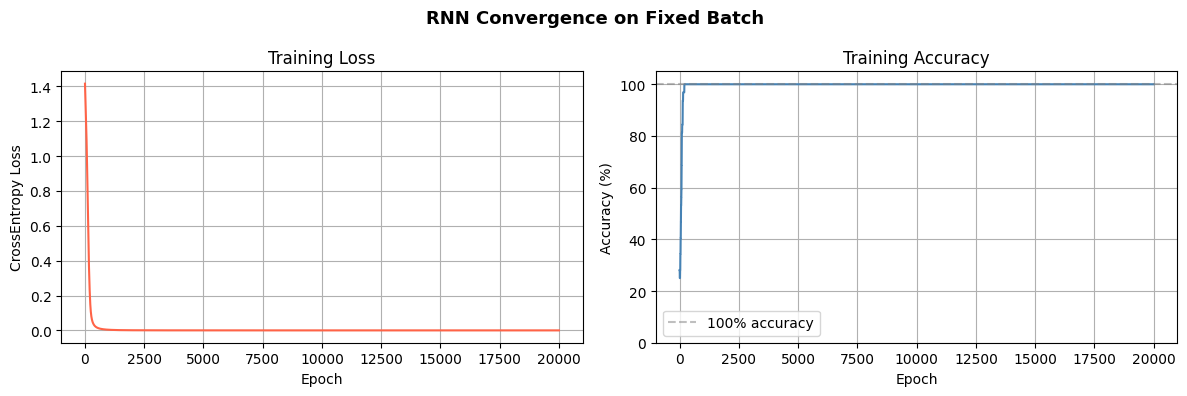

In [26]:
# Hyperparameters
batch_size  = 32
seq_len     = 10
input_size  = 8
hidden_size = 16
output_size = 4

# Model
model     = RNN(input_size, hidden_size)
fc_out    = nn.Linear(hidden_size, output_size)
optimizer = torch.optim.Adam(list(model.parameters()) + list(fc_out.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Dummy forward pass
x      = torch.randn(batch_size, seq_len, input_size)
labels = torch.randint(0, output_size, (batch_size,))


loss_history     = []
accuracy_history = []

num_epochs  = 20000


for epoch in range(num_epochs):
    model.train()

    outputs, h_n = model(x)
    logits       = fc_out(h_n)
    loss         = criterion(logits, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Accuracy
    preds    = logits.argmax(dim=1)
    accuracy = (preds == labels).float().mean().item() * 100

    loss_history.append(loss.item())
    accuracy_history.append(accuracy)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:>3}/{num_epochs}]  Loss: {loss.item():.4f}  Accuracy: {accuracy:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='tomato')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("CrossEntropy Loss")
ax1.grid(True)

ax2.plot(accuracy_history, color='steelblue')
ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='100% accuracy')
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True)

plt.suptitle("RNN Convergence on Fixed Batch", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
